In [12]:
from utils.lstm_utils.lstm_preprocessing_utils import WindowAlgPreprocessor

In [13]:
rf_preprocessor = WindowAlgPreprocessor(sensors_path="../../../../data/ml/features_machine_and_movement_complete.csv", target_path="../../../../data/ml/targets_movement_complete.csv")
sensors_df, target_df = rf_preprocessor.read_data()
sensors_df = rf_preprocessor.feature_selection()
rf_preprocessor.normalize_angle()
X = rf_preprocessor.group_and_pad(rf_preprocessor.sensor_df, group_col="Experiment_ID")[:,::10,:]
Y = rf_preprocessor.group_and_pad(rf_preprocessor.target_df, group_col="Experiment_ID")[:,:-2:5,1:]

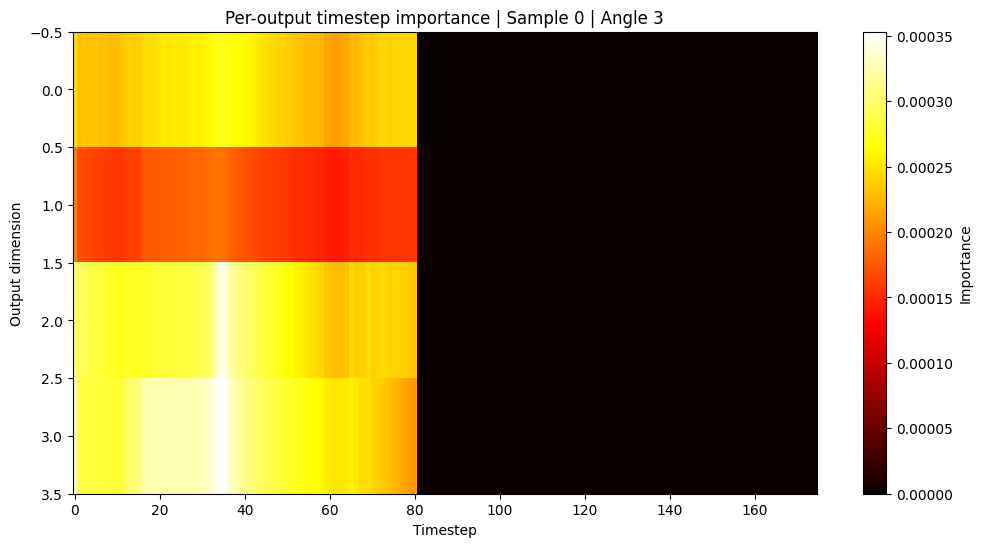

In [14]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from captum.attr import IntegratedGradients

# -----------------------------
# 1️⃣ Angle-aware LSTM model (angle at every timestep)
# -----------------------------
class AngleAwareLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, output_dim=4, num_layers=1):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.lstm_input_dim = input_dim + 2  # +2 for sin/cos(angle)
        self.lstm = nn.LSTM(input_size=self.lstm_input_dim, hidden_size=hidden_dim,
                            num_layers=num_layers, batch_first=True)
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, output_dim)
        )

    def forward(self, x, angle):
        # x: (batch, seq_len, input_dim)
        # angle: (batch, 1)

        batch_size, seq_len, _ = x.shape

        # create angle embedding per timestep
        angle = angle.to(x.dtype)
        angle_emb = torch.cat([torch.sin(angle * np.pi), torch.cos(angle * np.pi)], dim=1)
        angle_emb_seq = angle_emb.unsqueeze(1).repeat(1, seq_len, 1)  # (batch, seq_len, 2)

        # concatenate angle embedding to input
        x_combined = torch.cat([x, angle_emb_seq], dim=2)  # (batch, seq_len, input_dim+2)

        # pass through LSTM
        lstm_out, _ = self.lstm(x_combined)  # (batch, seq_len, hidden_dim)

        # sequence-level representation (mean over time)
        seq_repr = lstm_out.mean(dim=1)  # (batch, hidden_dim)

        return self.fc(seq_repr)  # (batch, output_dim)

# -----------------------------
# 2️⃣ Training function
# -----------------------------
def train_model(model, X, Y, angles, epochs=300, lr=1e-3):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        preds = model(X, angles)
        loss = loss_fn(preds, Y)
        loss.backward()
        optimizer.step()
        if epoch % 50 == 0:
            print(f"Epoch {epoch:03d} | Loss: {loss.item():.6f}")
    return model

# -----------------------------
# 3️⃣ Integrated Gradients for per-output timestep importance
# -----------------------------
def compute_time_importance_per_output(model, X_seq, angle_value):
    """
    Returns importance per timestep and per output dimension.
    Output: (seq_len, output_dim)
    """
    model.eval()
    ig = IntegratedGradients(model)

    X_seq = X_seq.unsqueeze(0).requires_grad_(True)  # (1, seq_len, input_dim)
    angle_tensor = torch.tensor([[angle_value]], dtype=torch.float32)

    output_dim = model(X_seq, angle_tensor).shape[1]
    all_importance = []

    # compute IG for each output separately
    for target_feature_idx in range(output_dim):
        attr, _ = ig.attribute(
            (X_seq, angle_tensor),
            target=target_feature_idx,
            n_steps=50,
            return_convergence_delta=True
        )
        importance = attr[0].detach().numpy().squeeze()  # (seq_len, input_dim)
        # sum abs over input features to get per-timestep importance
        timestep_importance = np.sum(np.abs(importance), axis=1)  # (seq_len,)
        all_importance.append(timestep_importance)

    return np.stack(all_importance, axis=1)  # (seq_len, output_dim)

# -----------------------------
# 4️⃣ Example usage
# -----------------------------
num_samples, seq_len, num_features = 50, 175, 16
num_angles, num_outputs = 9, 4

X_data = X
Y_data = Y

# reshape for training
X_flat, Y_flat, angle_flat = [], [], []
for i in range(num_samples):
    for j in range(num_angles):
        X_flat.append(X_data[i])               # same sequence, different angle
        Y_flat.append(Y_data[i, j])            # (4,)
        angle_flat.append([j / (num_angles - 1)])  # normalized 0 → 1

X_flat = torch.tensor(np.array(X_flat), dtype=torch.float32)  # (450, 1743, 16)
Y_flat = torch.tensor(np.array(Y_flat), dtype=torch.float32)  # (450, 4)
angle_flat = torch.tensor(np.array(angle_flat), dtype=torch.float32)  # (450, 1)

# -----------------------------
# 5️⃣ Train model
# -----------------------------
model = AngleAwareLSTM(input_dim=num_features, output_dim=num_outputs)
#train_model(model, X_flat, Y_flat, angle_flat)

# -----------------------------
# 6️⃣ Compute importance for one sample and angle
# -----------------------------
sample_idx = 0
angle_idx = 3  # pick any angle
importance_matrix = compute_time_importance_per_output(model, X_flat[sample_idx], angle_idx / (num_angles - 1))

# -----------------------------
# 7️⃣ Visualize as heatmap
# -----------------------------
plt.figure(figsize=(12, 6))
plt.imshow(importance_matrix.T, aspect='auto', cmap='hot')
plt.colorbar(label='Importance')
plt.xlabel("Timestep")
plt.ylabel("Output dimension")
plt.title(f"Per-output timestep importance | Sample {sample_idx} | Angle {angle_idx}")
plt.show()


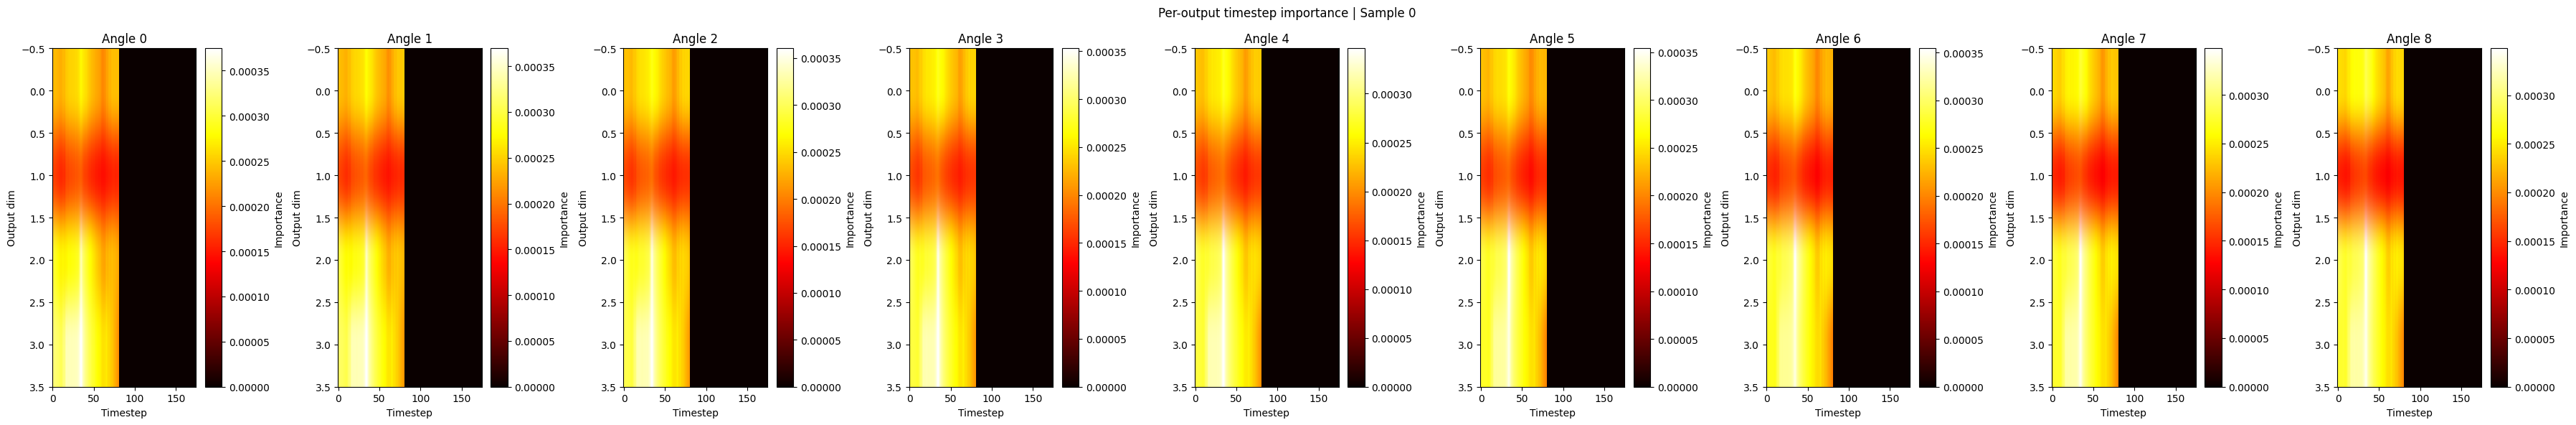

In [15]:
# -----------------------------
# 8️⃣ Heatmaps for multiple angles
# -----------------------------
def plot_multiple_angle_importance(model, X_seq, num_angles=9, sample_idx=0):
    plt.figure(figsize=(4 * num_angles, 6))
    for angle_idx in range(num_angles):
        angle_value = angle_idx / (num_angles - 1)
        importance_matrix = compute_time_importance_per_output(model, X_seq, angle_value)
        
        plt.subplot(1, num_angles, angle_idx + 1)
        plt.imshow(importance_matrix.T, aspect='auto', cmap='hot')
        plt.colorbar(label='Importance')
        plt.xlabel("Timestep")
        plt.ylabel("Output dim")
        plt.title(f"Angle {angle_idx}")
    
    plt.suptitle(f"Per-output timestep importance | Sample {sample_idx}")
    plt.tight_layout()
    plt.show()

# -----------------------------
# 9️⃣ Example usage for sample 0
# -----------------------------
plot_multiple_angle_importance(model, X_flat[sample_idx], num_angles=num_angles, sample_idx=sample_idx)


In [16]:
from utils.lstm_utils.lstm_preprocessing_utils import WindowAlgPreprocessor

lstm_preprocessor = WindowAlgPreprocessor(sensors_path="../../../../data/ml/features_machine_and_movement_complete.csv", target_path="../../../../data/ml/targets_movement_complete.csv")
sensors_df, target_df = lstm_preprocessor.read_data()
sensors_df = lstm_preprocessor.feature_selection()
lstm_preprocessor.normalize_angle()
X = lstm_preprocessor.group_and_pad(lstm_preprocessor.sensor_df, group_col="Experiment_ID")[:,:,:]
Y = lstm_preprocessor.group_and_pad(lstm_preprocessor.target_df, group_col="Experiment_ID")[:,:-2:,1:]
X = lstm_preprocessor.patchifier(X=X, window_size=10)

In [17]:
from utils.lstm_utils.model import AngleAwareLSTM
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import joblib
import numpy as np

def train_model(
    model, X_train, Y_train, angles_train,
    X_val, Y_val, angles_val,
    epochs=500, lr=1e-4, patience=20, device='cpu'
):
    model.to(device)
    X_train, Y_train, angles_train = X_train.to(device), Y_train.to(device), angles_train.to(device)
    X_val, Y_val, angles_val = X_val.to(device), Y_val.to(device), angles_val.to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    best_val_loss = float('inf')
    patience_counter = 0
    best_model_state = None

    for epoch in range(epochs):
        # Training
        model.train()
        optimizer.zero_grad()
        preds = model(X_train, angles_train)
        loss = loss_fn(preds, Y_train)
        loss.backward()
        optimizer.step()

        # Validation
        model.eval()
        with torch.no_grad():
            val_preds = model(X_val, angles_val)
            val_loss = loss_fn(val_preds, Y_val).item()

        # Early stopping check
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = model.state_dict()
            patience_counter = 0
        else:
            patience_counter += 1

        if epoch % 50 == 0 or epoch == epochs-1:
            print(f"Epoch {epoch:03d} | Train Loss: {loss.item():.6f} | Val Loss: {val_loss:.6f}")

        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch}. Best val loss: {best_val_loss:.6f}")
            break

    # Load best model state
    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    return model, best_val_loss

# -----------------------------
# Flatten dataset per angle
# -----------------------------
num_samples, seq_len, num_features = X.shape
num_angles, num_outputs = Y.shape[1:]

X_flat, Y_flat, angle_flat = [], [], []
for i in range(num_samples):
    for j in range(num_angles):
        X_flat.append(X[i])
        Y_flat.append(Y[i, j])
        angle_flat.append([j / (num_angles - 1)])

X_flat = torch.tensor(np.array(X_flat), dtype=torch.float32)
Y_flat = torch.tensor(np.array(Y_flat), dtype=torch.float32)
angle_flat = torch.tensor(np.array(angle_flat), dtype=torch.float32)

# -----------------------------
# Split into train/validation
# -----------------------------
X_train, X_val, Y_train, Y_val, angles_train, angles_val = train_test_split(
    X_flat, Y_flat, angle_flat, test_size=0.2, random_state=42
)

# -----------------------------
# Initialize model and train
# -----------------------------
model = AngleAwareLSTM(input_dim=num_features, output_dim=num_outputs, bidirectional=True)
model = joblib.load(f"../../../../models/lstm/bi_lstm_movement_machine_{num_angles}_angle.joblib")

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from ipywidgets import interact, IntSlider

def plot_sample_prediction(sample_idx=0):
    # Select sample
    X_sample = X_val[sample_idx]
    angle_sample = angles_val[sample_idx]
    Y_true = Y_val[sample_idx]

    # Model prediction
    model.eval()
    with torch.no_grad():
        Y_pred = model(X_sample.unsqueeze(0), angle_sample.unsqueeze(0)).squeeze(0)

    Y_true_np = Y_true.numpy()
    Y_pred_np = Y_pred.numpy()

    # Plot
    plt.figure(figsize=(8,5))
    plt.plot(np.arange(len(Y_true_np)), Y_true_np, label='True', marker='o')
    plt.plot(np.arange(len(Y_pred_np)), Y_pred_np, label='Predicted', marker='x')
    plt.xlabel('Output dimension')
    plt.ylabel('Value')
    plt.title(f'Sample {sample_idx} | True vs Predicted')
    plt.legend()
    plt.grid(True)
    plt.show()

# Interactive slider
interact(
    plot_sample_prediction,
    sample_idx=IntSlider(min=0, max=len(X_val)-1, step=1, value=0, description='Test Sample')
)


interactive(children=(IntSlider(value=0, description='Test Sample', max=2834), Output()), _dom_classes=('widge…

<function __main__.plot_sample_prediction(sample_idx=0)>

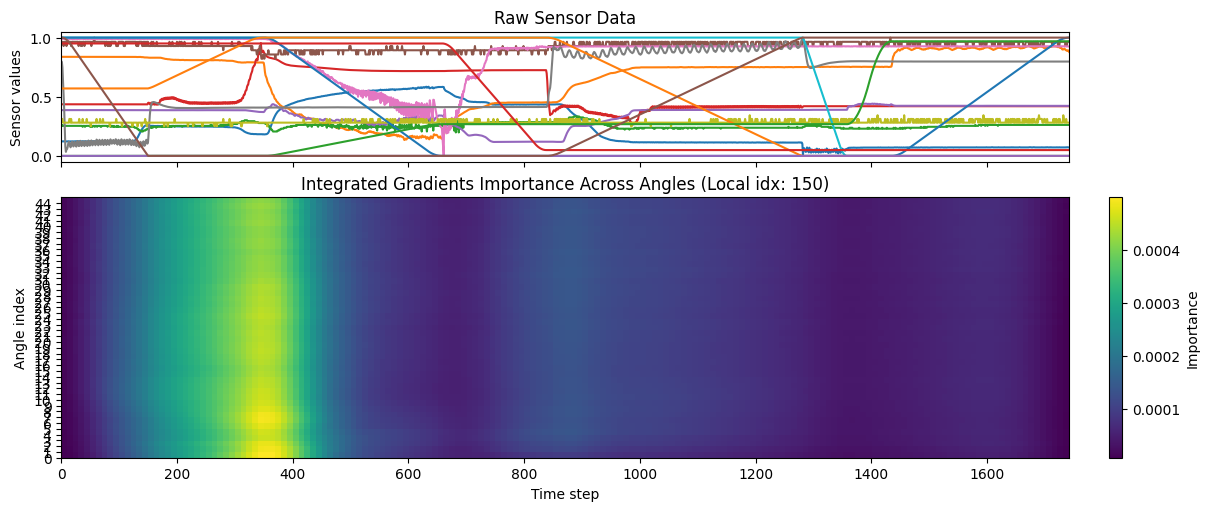

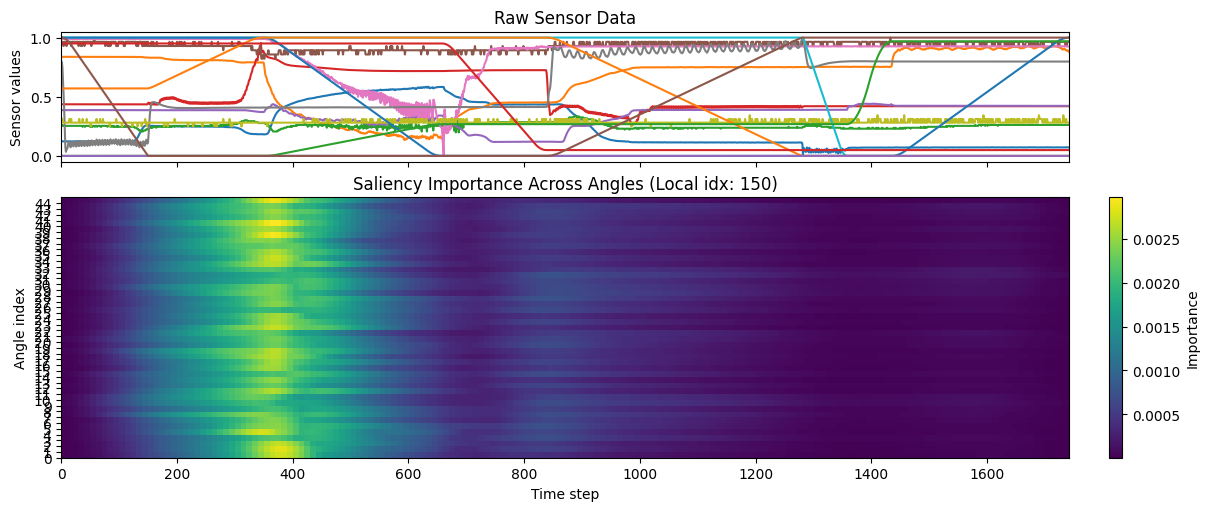

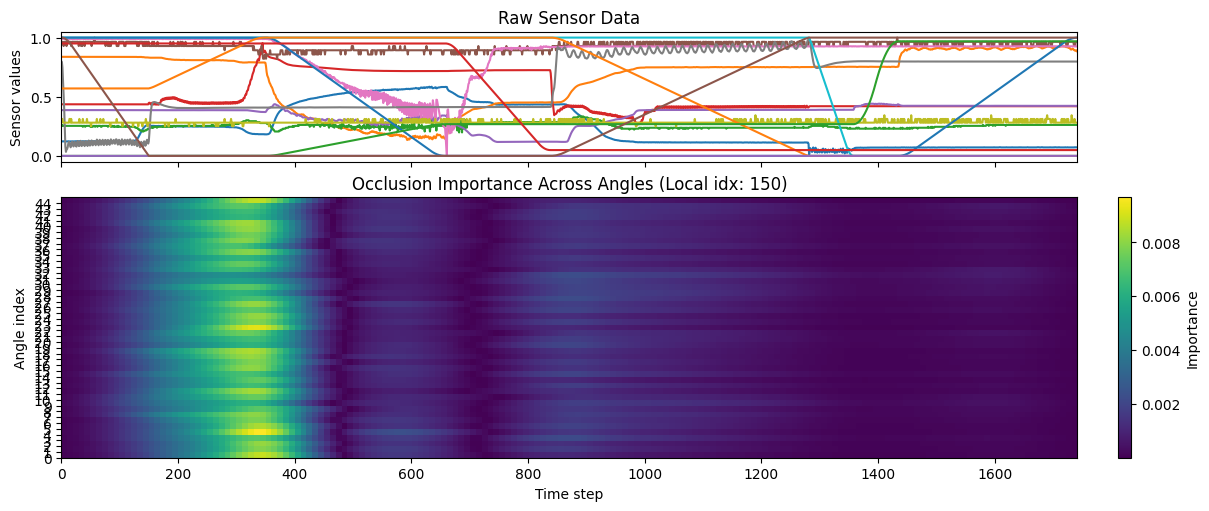

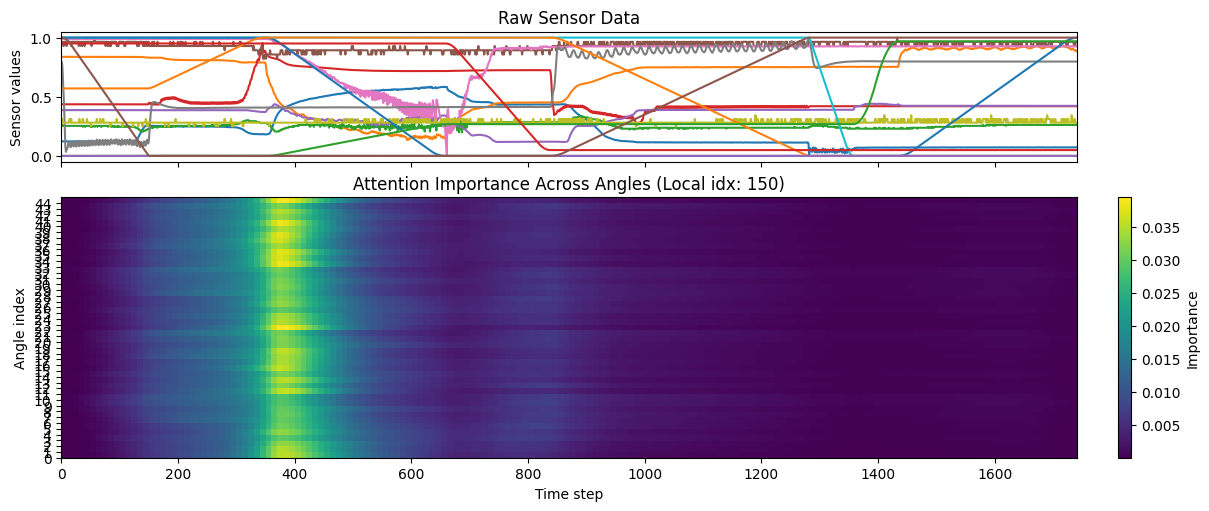

In [19]:
from utils.lstm_utils.window_importance_utils import plot_all_importances_for_sample_safe

sample_idx_local = 150 
num_angles = Y.shape[1] if Y.ndim > 1 else 10
angle_indices = [*range(num_angles)]

plot_all_importances_for_sample_safe(
    model,
    sample_idx_local,
    angle_indices,
    X_flat,
    num_angles,
    sensors_df=sensors_df,
    target_feature_idx=0
)

In [ ]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from ipywidgets import interact, FloatSlider, IntSlider
from captum.attr import GuidedBackprop, DeepLift, IntegratedGradients, Saliency, InputXGradient, FeatureAblation, KernelShap, GradientShap

# -----------------------------
# 1️⃣ Attribution methods
# -----------------------------
def compute_ig_importance(model, X_seq, angle_value, target_feature_idx=0):
    model.eval()
    ig = IntegratedGradients(model)
    X_seq_tensor = X_seq.unsqueeze(0).requires_grad_(True)
    angle_tensor = torch.tensor([[angle_value]], dtype=torch.float32)
    attr = ig.attribute((X_seq_tensor, angle_tensor), target=target_feature_idx, n_steps=50)
    return np.abs(attr[0].detach().numpy().squeeze())  # (seq_len, input_dim)

def compute_grad_input_importance(model, X_seq, angle_value, target_feature_idx=0):
    model.eval()
    X_seq_tensor = X_seq.unsqueeze(0).requires_grad_(True)
    angle_tensor = torch.tensor([[angle_value]], dtype=torch.float32)
    output = model(X_seq_tensor, angle_tensor)
    output[0, target_feature_idx].backward()
    grad = X_seq_tensor.grad.detach().numpy().squeeze()
    importance = np.abs(grad * X_seq_tensor.detach().numpy().squeeze())
    return importance  # (seq_len, input_dim)

def compute_saliency(model, X_seq, angle_value, target_feature_idx=0):
    model.eval()
    X_seq_tensor = X_seq.unsqueeze(0).requires_grad_(True)
    angle_tensor = torch.tensor([[angle_value]], dtype=torch.float32)
    output = model(X_seq_tensor, angle_tensor)
    output[0, target_feature_idx].backward()
    saliency = np.abs(X_seq_tensor.grad.detach().numpy().squeeze())
    return saliency  # (seq_len, input_dim)

def compute_occlusion_importance(model, X_seq, angle_value, target_feature_idx=0, window=1):
    """
    Compute feature-wise Occlusion importance for a sequence.

    Args:
        model: PyTorch model
        X_seq: (seq_len, num_features) input sequence tensor
        angle_value: normalized angle [0,1]
        target_feature_idx: index of the target output
        window: number of timesteps to occlude at once (centered on t)

    Returns:
        importance: (seq_len, num_features) importance map
    """
    model.eval()
    seq_len, input_dim = X_seq.shape
    importance = np.zeros((seq_len, input_dim))
    angle_tensor = torch.tensor([[angle_value]], dtype=torch.float32)

    # Original model output
    original_output = model(X_seq.unsqueeze(0), angle_tensor).detach()[0, target_feature_idx]

    # Loop over timesteps and features
    for t in range(seq_len):
        start = max(0, t - window // 2)
        end = min(seq_len, t + window // 2 + 1)
        for f in range(input_dim):
            X_perturbed = X_seq.clone()
            X_perturbed[start:end, f] = 0  # zero only this feature over the window
            pert_output = model(X_perturbed.unsqueeze(0), angle_tensor).detach()[0, target_feature_idx]
            importance[t, f] = np.abs(original_output - pert_output)

    return importance


def compute_attention_importance(model, X_seq, angle_value):
    model.eval()
    with torch.no_grad():
        angle_tensor = torch.tensor([[angle_value]], dtype=torch.float32)
        _, attn_weights = model(X_seq.unsqueeze(0), angle_tensor, return_attention=True)
        attn_weights = attn_weights.detach().numpy()
        attn_weights = np.squeeze(attn_weights)  # remove batch dims
        attn_weights = np.tile(attn_weights, (X_seq.shape[1], 1))  # repeat for each feature
        return attn_weights  # shape (features, seq_len) -> valid for imshow


def compute_attribution(model, X_seq, angle_value, target_feature_idx=0, method='IG'):
    model.eval()
    X_seq_tensor = X_seq.unsqueeze(0).requires_grad_(True)
    angle_tensor = torch.tensor([[angle_value]], dtype=torch.float32)
    
    if method == 'IG':
        attr = IntegratedGradients(model).attribute((X_seq_tensor, angle_tensor), target=target_feature_idx, n_steps=50)
    elif method == 'GradInput':
        attr = InputXGradient(model).attribute((X_seq_tensor, angle_tensor), target=target_feature_idx)
    elif method == 'Saliency':
        attr = Saliency(model).attribute((X_seq_tensor, angle_tensor), target=target_feature_idx)
    elif method == 'DeepLift':
        attr = DeepLift(model).attribute((X_seq_tensor, angle_tensor), target=target_feature_idx)
    elif method == 'FeatureAblation':
        attr = FeatureAblation(model).attribute((X_seq_tensor, angle_tensor), target=target_feature_idx)
    elif method == 'KernelShap':
        attr = KernelShap(model).attribute((X_seq_tensor, angle_tensor), target=0, n_samples=5000)
    elif method == 'Occlusion':
        return compute_occlusion_importance(model, X_seq, angle_value, target_feature_idx, window=3)
    elif method == 'Attention':
        _, attn_weights = model(X_seq.unsqueeze(0), angle_tensor, return_attention=True)
        attn_weights = np.tile(attn_weights.detach().numpy().squeeze(), (X_seq.shape[1], 1))
        return attn_weights
    else:
        raise ValueError(f"Unknown method: {method}")
    
    return np.abs(attr[0].detach().numpy().squeeze())

def plot_feature_importance_heatmap(model, X_seq, angle_value=0.0, target_feature_idx=0, method='IG', feature_names=None):
    feature_imp = compute_attribution(model, X_seq, angle_value, target_feature_idx, method)
    
    plt.figure(figsize=(12, 6))
    plt.imshow(feature_imp.T, aspect='auto', cmap='hot', interpolation='nearest')
    plt.colorbar(label='Importance')
    plt.xlabel('Time step')
    plt.ylabel('Feature')
    
    if feature_names is not None:
        plt.yticks(ticks=np.arange(len(feature_names)), labels=feature_names)
    
    plt.title(f'{method} Feature Importance | Angle={angle_value:.2f} | Target={target_feature_idx}')
    plt.show()

all_columns = lstm_preprocessor.sensor_df.columns.tolist()
feature_columns = [col for col in all_columns if col != "Experiment_ID"]

from ipywidgets import interact, FloatSlider, IntSlider

def interactive_feature_importance(local_sample_idx=0, angle_idx=0, target_feature_idx=0, method='IG'):
    flat_idx = local_sample_idx * max(1, num_angles) + angle_idx
    if flat_idx >= len(X_flat):
        raise IndexError(f"Computed flat index {flat_idx} exceeds X_flat length {len(X_flat)}")
    
    X_seq = X_flat[flat_idx]
    angle_value = 0.0 if num_angles <= 1 else angle_idx / (num_angles - 1)
    
    plot_feature_importance_heatmap(model, X_seq, angle_value, target_feature_idx, method, feature_names=feature_columns)

interact(
    interactive_feature_importance,
    local_sample_idx=IntSlider(min=0, max=(len(X_flat)//num_angles)-1, step=1, value=0, description='Sample'),
    angle_idx=IntSlider(min=0, max=max(0, num_angles-1), step=1, value=0, description='Angle'),
    target_feature_idx=IntSlider(min=0, max=Y_flat.shape[1]-1, step=1, value=0, description='Target'),
    method=['IG', 'GradInput', 'Saliency', 'DeepLift', 'FeatureAblation', 'KernelShap', 'Occlusion', 'Attention']
)


interactive(children=(IntSlider(value=0, description='Sample', max=314), IntSlider(value=0, description='Angle…

<function __main__.interactive_feature_importance(local_sample_idx=0, angle_idx=0, target_feature_idx=0, method='IG')>